Task 1: Improve the CNN model from previous worksheet

In [ ]:
# Import Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Define Dataset Paths
train_dir = "/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/FruitinAmazon/test"

In [ ]:
# Verify Dataset Directory
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes:", class_names)

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
# Check Corrupted Images
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
# Check Class Distribution
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','.jpeg'))]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k, v in class_counts.items():
    print(k, ":", v)


Class Distribution:
acai : 15
cupuacu : 15
graviola : 15
guarana : 15
pupunha : 15
tucuma : 15


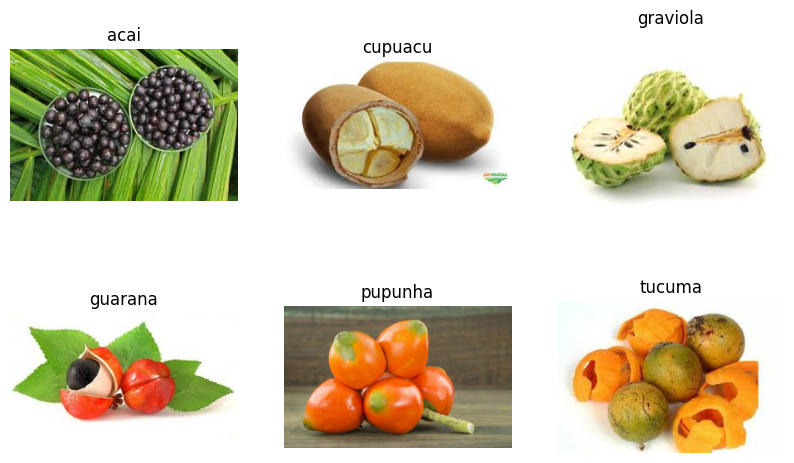

In [ ]:
# Visualize Random Images
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

plt.figure(figsize=(10,6))
for i in range(len(selected_images)):
    plt.subplot(2,3,i+1)
    img = mpimg.imread(selected_images[i])
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")
plt.show()

Data Generation and Preprocessing

In [ ]:
# Load Train and Validation Dataset
image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
# Check Dataset Shape
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


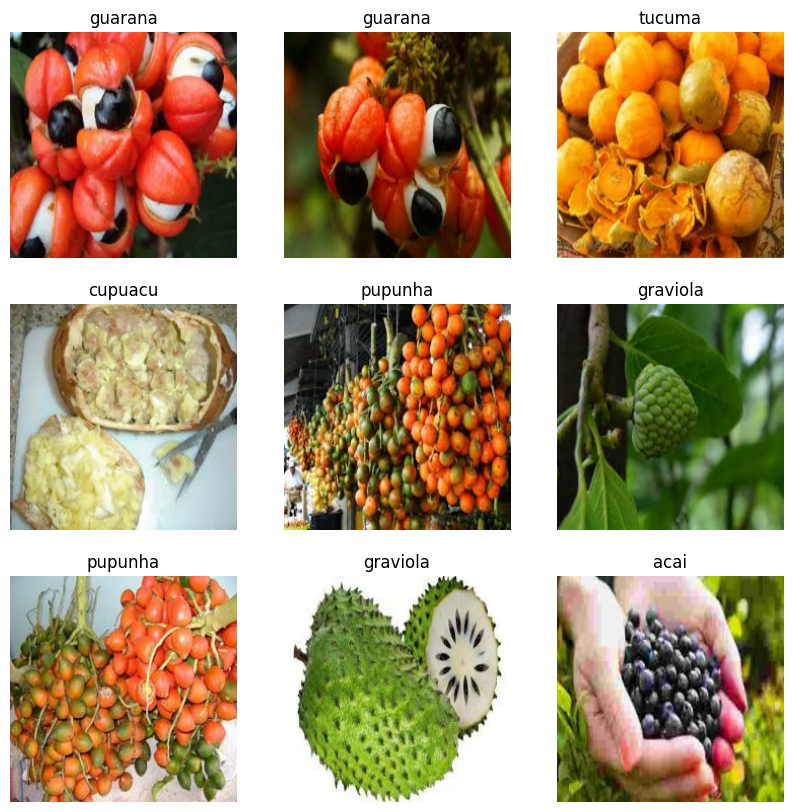

In [ ]:
#  Visualize Training Data
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Data Augmentation

In [ ]:
# Define Augmentation Layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

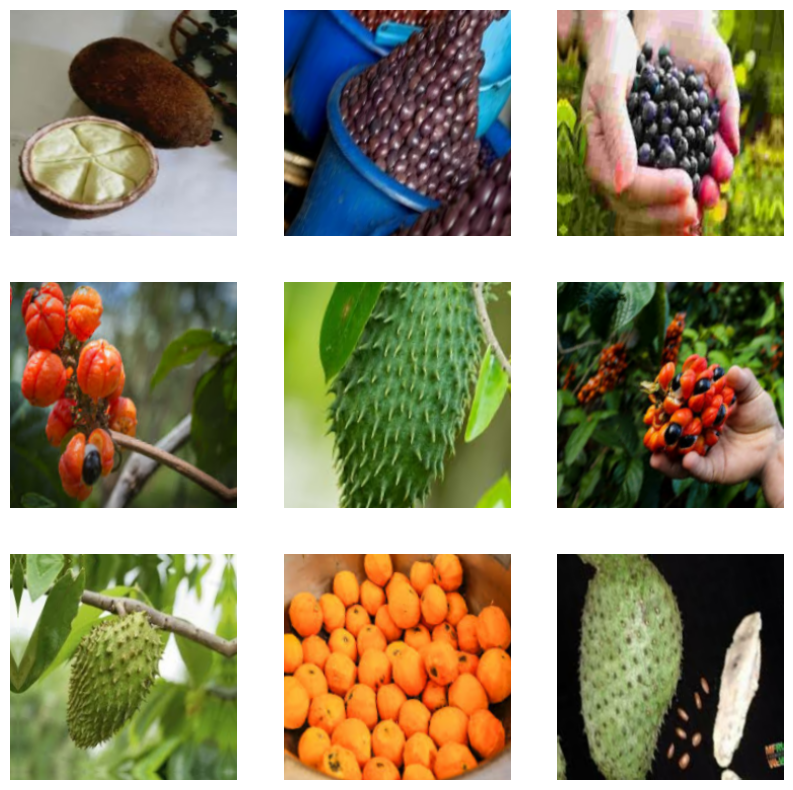

In [ ]:
# Visualize Augmented Images
plt.figure(figsize=(10,10))
for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

Build CNN Model (Improved)

In [ ]:
# Define Model with BatchNorm & Dropout
model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    Conv2D(32,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

In [ ]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.2361 - loss: 2.3532 - val_accuracy: 0.2222 - val_loss: 2.6236
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5000 - loss: 1.2992 - val_accuracy: 0.2778 - val_loss: 2.1424
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5278 - loss: 1.1833 - val_accuracy: 0.1111 - val_loss: 2.2408
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.6111 - loss: 1.0893 - val_accuracy: 0.0556 - val_loss: 2.1066
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.6806 - loss: 0.9051 - val_accuracy: 0.1111 - val_loss: 2.0797
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.6667 - loss: 0.9260 - val_accuracy: 0.1111 - val_loss: 2.1788
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.7500 - loss: 0.6908 - val_accuracy: 0.1111 - val_loss: 2.3373
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.7222 - loss: 0.7957 - val_accuracy: 0.1111 - val_loss: 2.4888
Epoch 9/

In [ ]:
# Evaluate Model
cnn_loss, cnn_acc = model.evaluate(val_ds)
print("CNN Accuracy:", cnn_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3889 - loss: 1.7893
CNN Accuracy: 0.3888888955116272


In [ ]:
# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.20      0.50      0.29         2
    graviola       0.00      0.00      0.00         3
     guarana       1.00      0.40      0.57         5
     pupunha       0.36      1.00      0.53         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.39        18
   macro avg       0.26      0.32      0.23        18
weighted avg       0.38      0.39      0.31        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Task 2: Transfer Learning using VGG16

In [ ]:
#Load Pretrained Model
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
# Freeze Layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Add Custom Layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

In [ ]:
# Create Model
from tensorflow.keras.models import Model

vgg_model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
# Compile Model
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Model
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 24s/step - accuracy: 0.1528 - loss: 10.1032 - val_accuracy: 0.2778 - val_loss: 5.8597
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 21s/step - accuracy: 0.3611 - loss: 6.7561 - val_accuracy: 0.2222 - val_loss: 4.8862
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 25s/step - accuracy: 0.5417 - loss: 3.7445 - val_accuracy: 0.4444 - val_loss: 3.0024
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 23s/step - accuracy: 0.6389 - loss: 1.7832 - val_accuracy: 0.6667 - val_loss: 2.3657
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 24s/step - accuracy: 0.7500 - loss: 1.1196 - val_accuracy: 0.7222 - val_loss: 2.3958
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 20s/step - accuracy: 0.7083 - loss: 1.5652 - val_accuracy: 0.6111 - val_loss: 2.7057
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 21s/step - accuracy: 0.7917 - loss: 0.7868 - val_accuracy: 0.6667 - val_loss: 3.0929
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 25s/step - accuracy: 0.8611 - loss: 0.6563 - val_accuracy: 0.6111 - val_loss: 3.4936

In [ ]:
# Evaluate Model
vgg_loss, vgg_acc = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", vgg_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.6111 - loss: 3.3668
VGG16 Accuracy: 0.6111111044883728


In [ ]:
# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         1
     cupuacu       0.29      1.00      0.44         2
    graviola       0.67      0.67      0.67         3
     guarana       1.00      0.60      0.75         5
     pupunha       1.00      0.25      0.40         4
      tucuma       0.67      0.67      0.67         3

    accuracy                           0.61        18
   macro avg       0.77      0.70      0.65        18
weighted avg       0.81      0.61      0.62        18



In [ ]:
# Comparison
print("CNN Accuracy:", cnn_acc)
print("VGG Accuracy:", vgg_acc)

CNN Accuracy: 0.3888888955116272
VGG Accuracy: 0.6111111044883728
